# Penguin PCA

Peter Ralph  
2026-01-28

# Quick exercise: penguins

Have a look at the [Palmer
Penguins](https://allisonhorst.github.io/palmerpenguins/articles/intro.html)
dataset (which is provided already in `plotnine`).

Workflow:

1.  load in data, remove NAs
2.  do PCA: include proportion variance explained
3.  make plots of the first two PCs, colored by categorical variables
    (species, island, sex, …)
4.  look at loadings (just do this by hand, no need to pull in the fancy
    `biplot` function) to interpret the PCs

In [1]:
import pandas as pd
import sklearn.decomposition
import plotnine as p9
from plotnine.data import penguins

## In class

In [2]:
orig_penguins = penguins.dropna().reset_index()
orig_penguins

,index,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
...,...,...,...,...,...,...,...,...,...
328,339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
329,340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
330,341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
331,342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [3]:
X = orig_penguins.select_dtypes("float")
pca = sklearn.decomposition.PCA().fit(X)
ppcs = pd.DataFrame(
    pca.transform(X),
    columns=[f"PC{k+1}" for k in range(pca.n_components_)]) 
ploadings_temp = pca.components_ # rows are PCs, columns are variables

In [4]:
penguins = pd.concat([
    orig_penguins,
    ppcs,
], axis=1)

In [5]:
ploadings = pd.DataFrame(
    ploadings_temp,
    index=[f"PC{k+1}" for k in range(pca.n_components_)],
    columns=X.columns,
).T.reset_index() # TRANSPOSE!

In [6]:
ploadings

,index,PC1,PC2,PC3,PC4
0,bill_length_mm,0.004003,0.319278,0.941265,-0.109847
1,bill_depth_mm,-0.001154,-0.086848,0.144495,0.985686
2,flipper_length_mm,0.015195,0.943542,-0.305190,0.127891
3,body_mass_g,0.999876,-0.015717,0.001036,-0.000366


Let's see how the loadings are used to construct the PC coordinates,
with the rightmost-on-PC1 penguin as an example:

In [7]:
penguins.query("PC1 > 2000")

,index,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,PC1,PC2,PC3,PC4
163,169,Gentoo,Biscoe,49.2,15.2,221.0,6300.0,male,2007,2093.010665,-12.159624,0.672088,-0.712186


In [8]:
penguins.loc[:,('bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g')].mean()

bill_length_mm         43.992793
bill_depth_mm          17.164865
flipper_length_mm     200.966967
body_mass_g          4207.057057
dtype: float64

In [9]:
(49.2 - 43.992) * .004003 + (15.2 - 17.16) * (-.001154) + (221 - 200.966) * .015195 + (6300 - 4207) * 0.999876

2093.067994094

In [10]:
ppcs.shape, ploadings.shape

((333, 4), (4, 5))

Okay, we have PC coordinates, let's stick that on the right hand side of our data frame.

In [11]:
penguins.index.isin(ppcs.index).sum()

np.int64(333)

Species more or less cluster separately on the PCs:

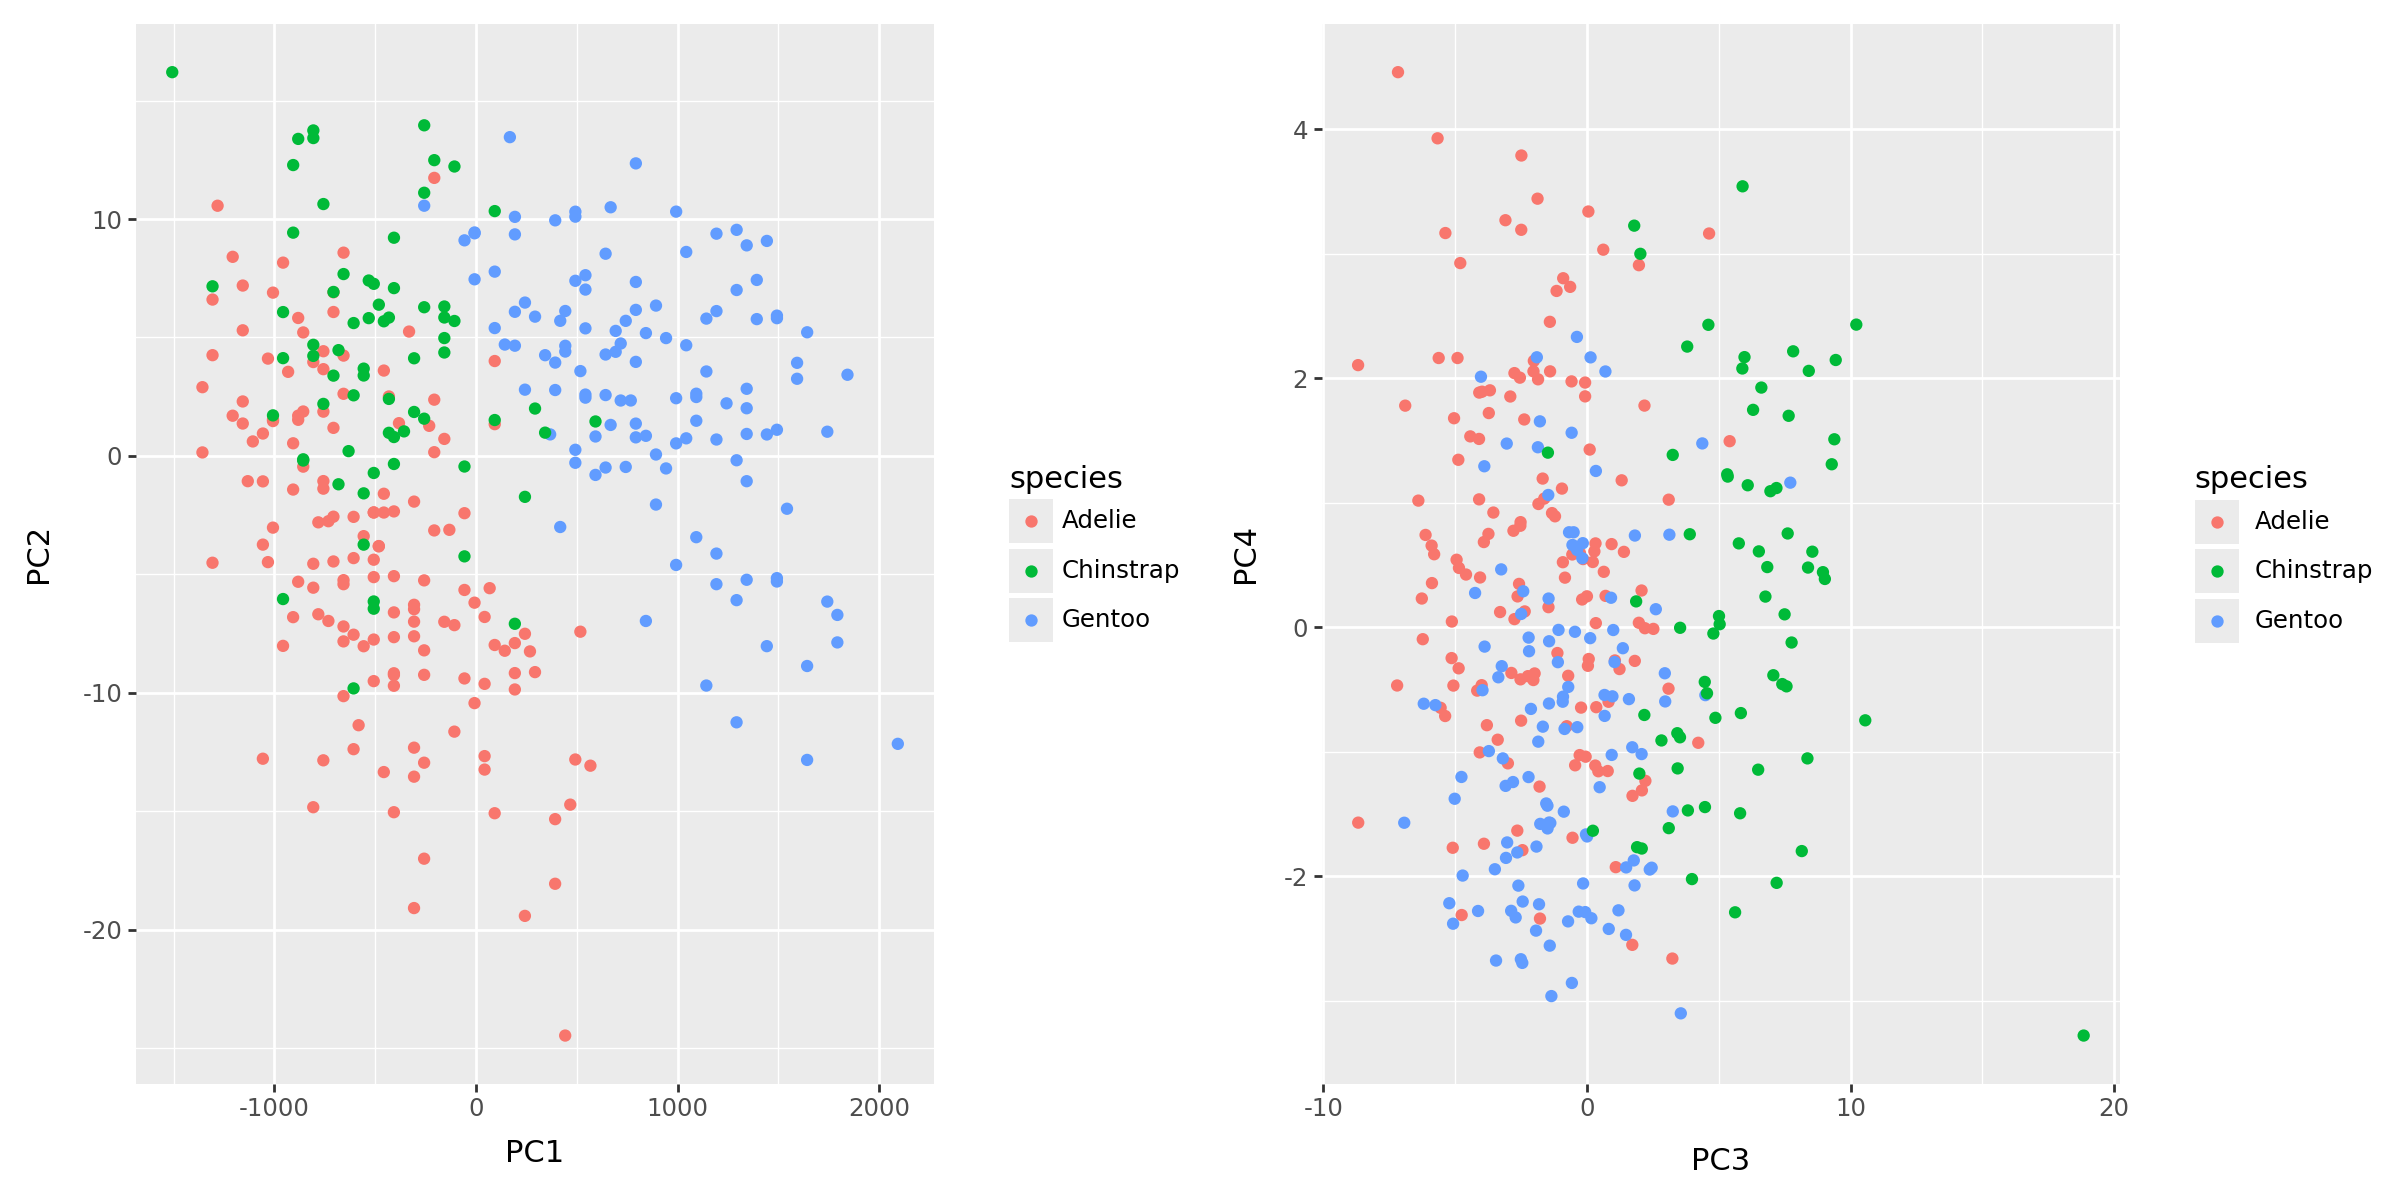

In [12]:
(
    p9.ggplot(penguins, p9.aes(x="PC1", y="PC2", color="species")) + p9.geom_point()
) | (
    p9.ggplot(penguins, p9.aes(x="PC3", y="PC4", color="species")) + p9.geom_point()
) + p9.theme(figure_size=(12,6))

Males tend to be a bit further to the right on PC1:

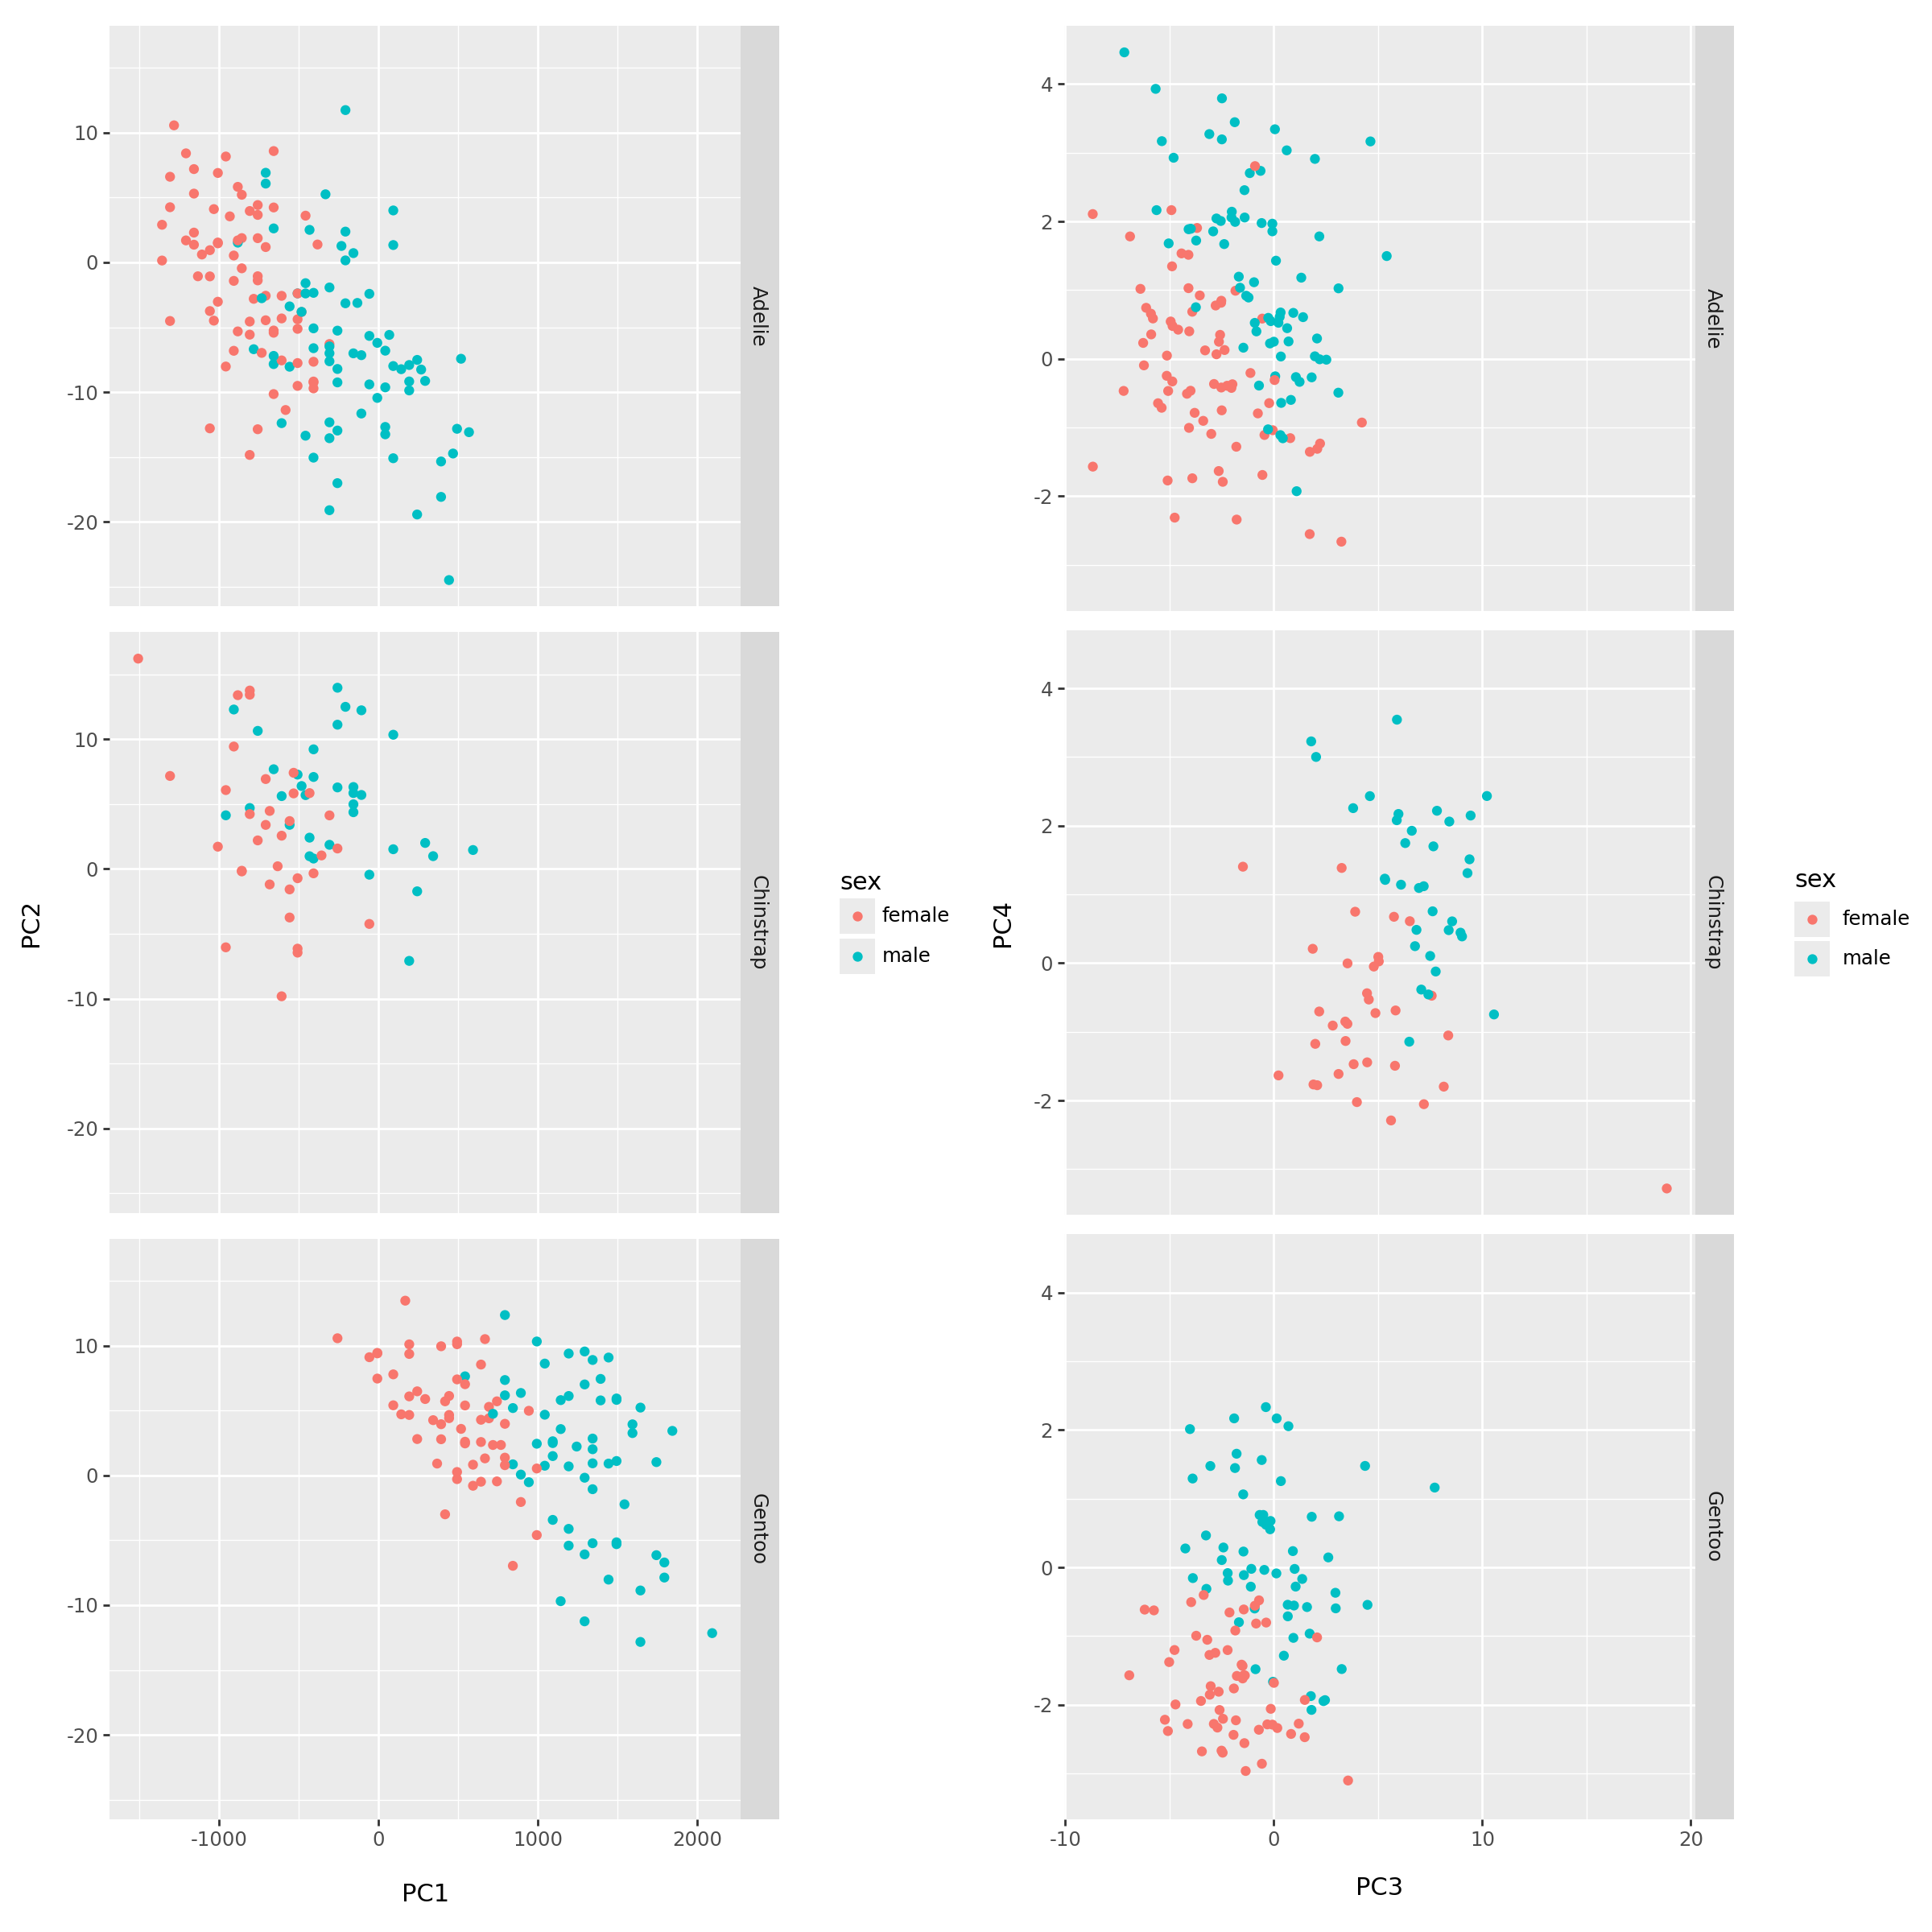

In [13]:
var = "sex"
(
    p9.ggplot(penguins, p9.aes(x="PC1", y="PC2", color=var)) + p9.geom_point() + p9.facet_grid("species")
) | (
    p9.ggplot(penguins, p9.aes(x="PC3", y="PC4", color=var)) + p9.geom_point() + p9.facet_grid("species")
) + p9.theme(figure_size=(12,12))

Happily, there is no clustering by year:

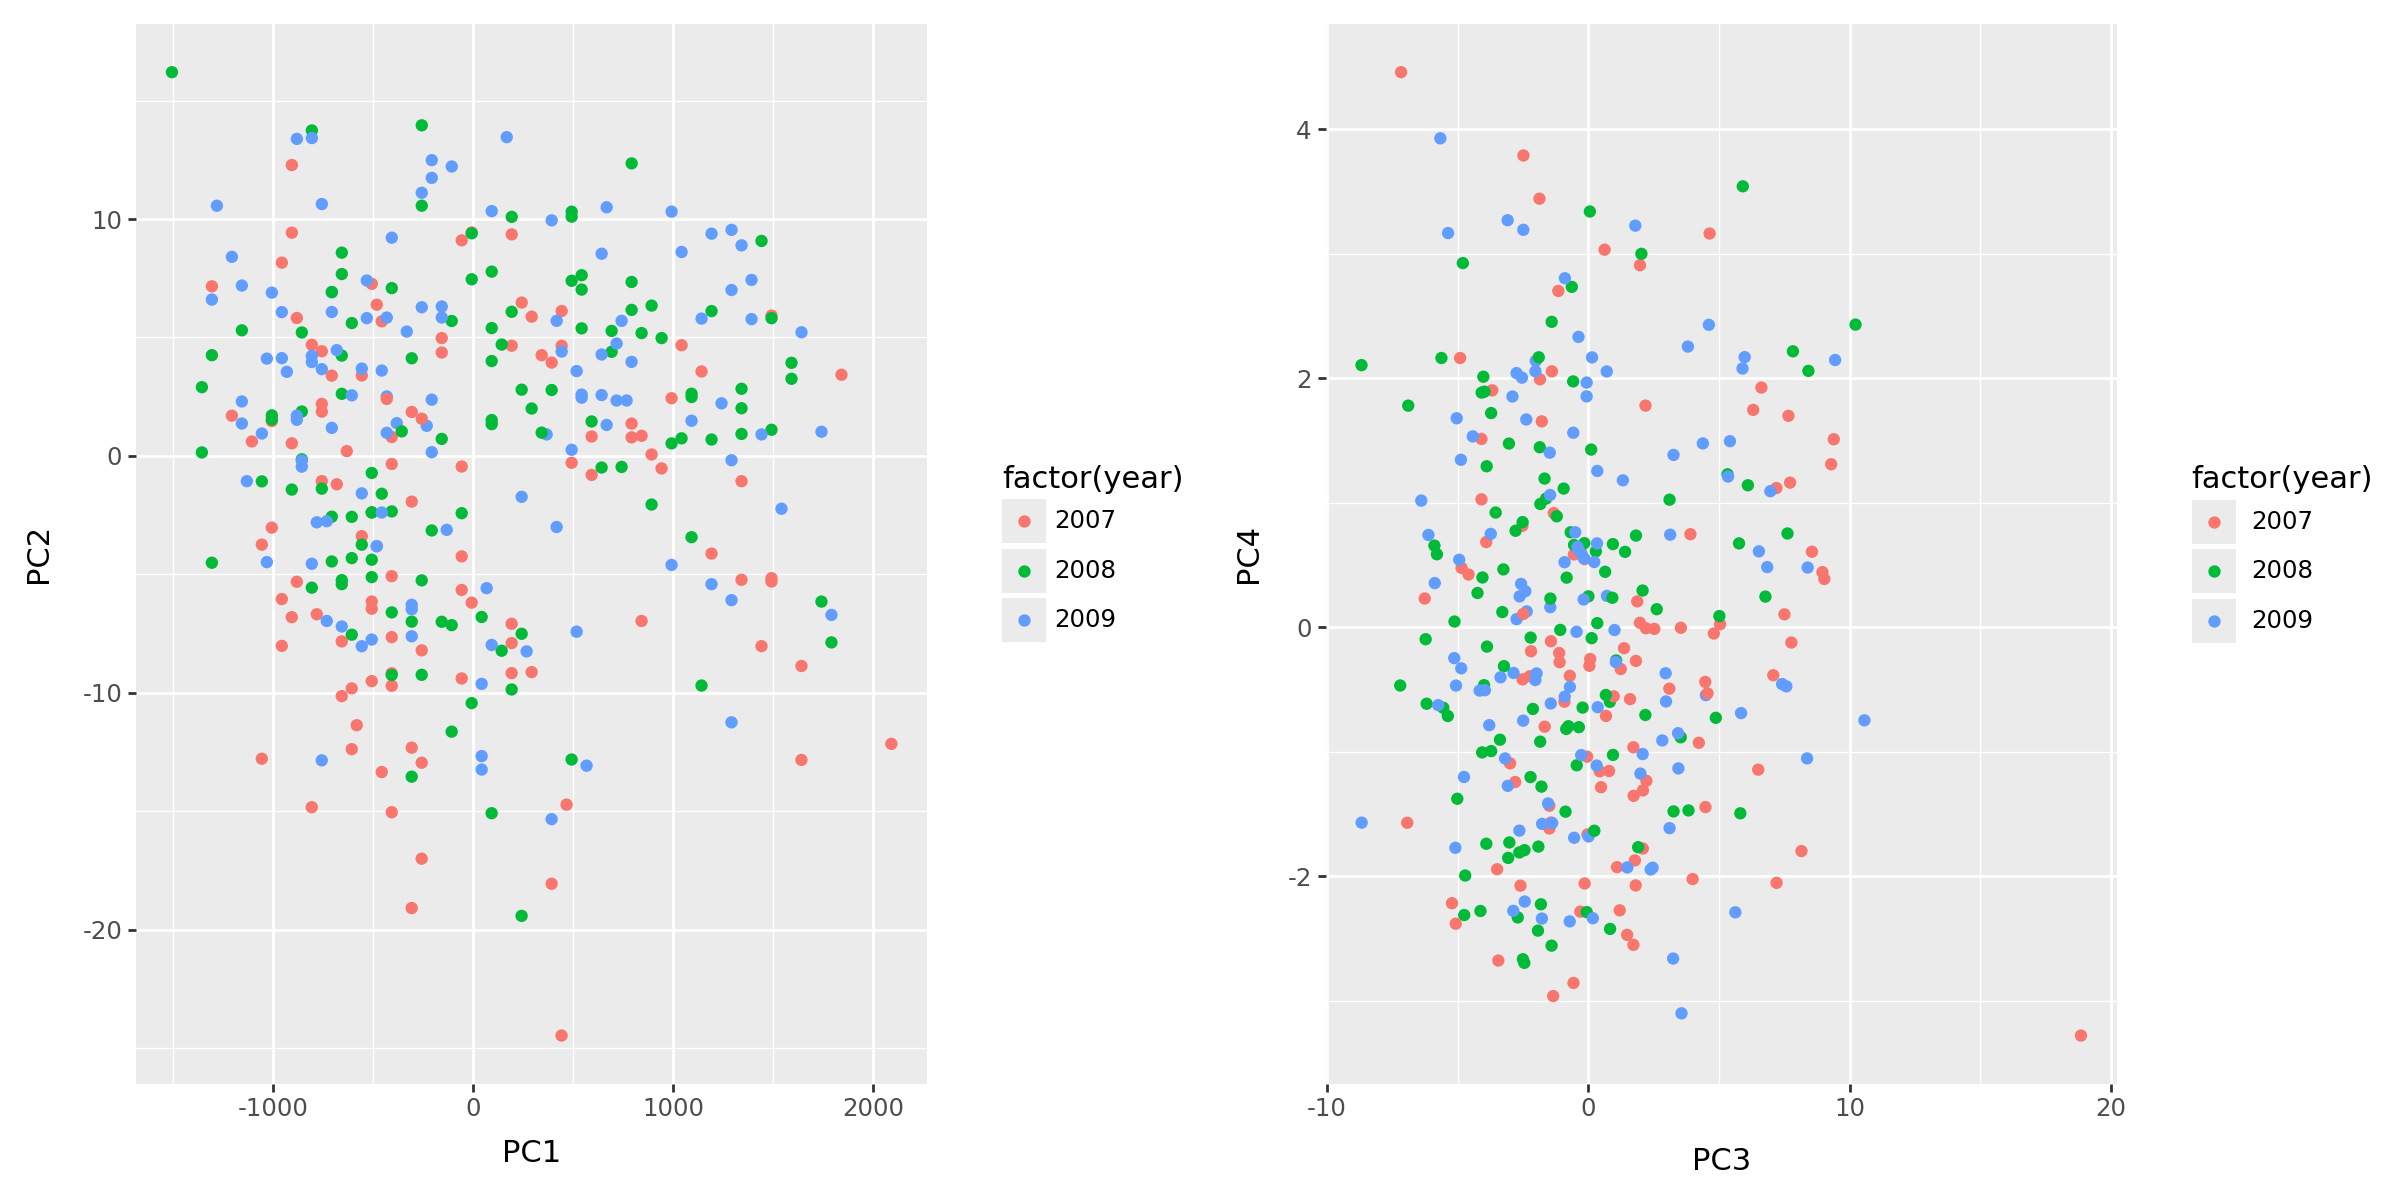

In [14]:
(
    p9.ggplot(penguins, p9.aes(x="PC1", y="PC2", color="factor(year)")) + p9.geom_point()
) | (
    p9.ggplot(penguins, p9.aes(x="PC3", y="PC4", color="factor(year)")) + p9.geom_point()
) + p9.theme(figure_size=(12,6))

# After rescaling variables

Whoops, weight is a lot bigger than other variables,
so PC1 was just weight. Let's rescale variables
so they have a common currency.

In [15]:
X = orig_penguins.select_dtypes("float").transform(lambda x: x / x.std())
pca = sklearn.decomposition.PCA().fit(X)
ppcs = pd.DataFrame(
    pca.transform(X),
    columns=[f"PC{k+1}" for k in range(pca.n_components_)]) 
ploadings_temp = pca.components_ # rows are PCs, columns are variables

In [16]:
penguins = pd.concat([
    orig_penguins,
    ppcs,
], axis=1)

In [17]:
ploadings = pd.DataFrame(
    ploadings_temp,
    index=[f"PC{k+1}" for k in range(pca.n_components_)],
    columns=X.columns,
).T.reset_index() # TRANSPOSE!

In [18]:
ploadings

,index,PC1,PC2,PC3,PC4
0,bill_length_mm,0.453753,0.600195,0.642495,-0.145170
1,bill_depth_mm,-0.399047,0.796170,-0.425800,0.159904
2,flipper_length_mm,0.576825,0.005788,-0.236095,0.781984
3,body_mass_g,0.549675,0.076464,-0.591737,-0.584686


Okay, we have PC coordinates, let's stick that on the right hand side of our data frame.

Species more or less cluster separately on the PCs:

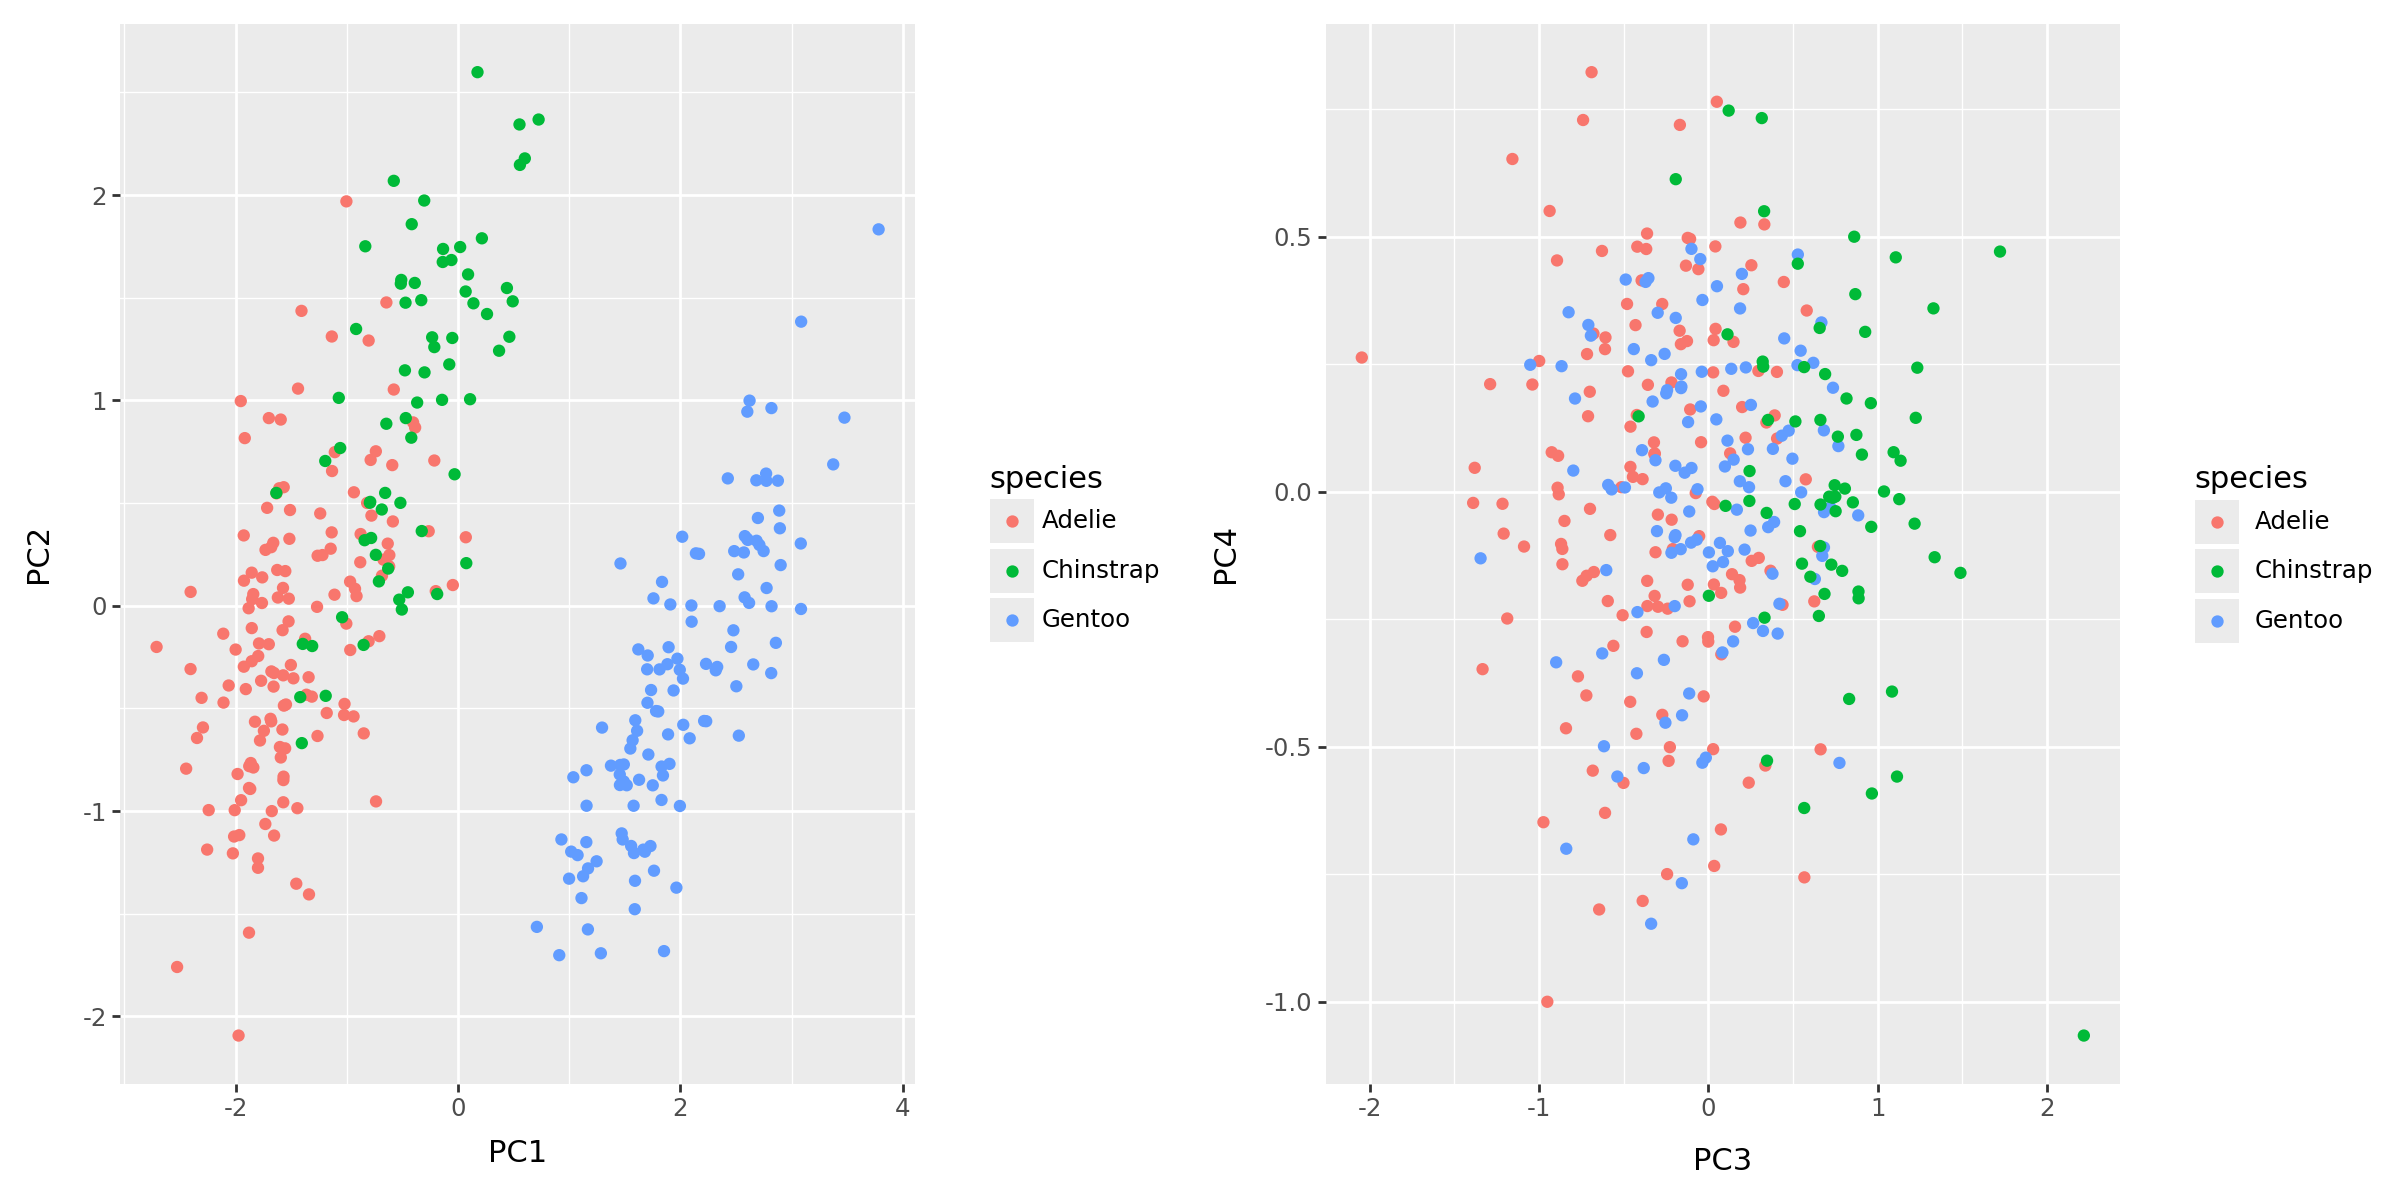

In [19]:
(
    p9.ggplot(penguins, p9.aes(x="PC1", y="PC2", color="species")) + p9.geom_point()
) | (
    p9.ggplot(penguins, p9.aes(x="PC3", y="PC4", color="species")) + p9.geom_point()
) + p9.theme(figure_size=(12,6))

# Some code that will come in handy

In [20]:
def biplot(pcs, loadings, a=1, b=2, labels=None, color=None):
    assert labels is None or color is None
    f = (pcs.select_dtypes("float").std(axis=0) / loadings.select_dtypes("float").std(axis=0)).mean()
    p = p9.ggplot(pcs, p9.aes(x=f"PC{a}", y=f"PC{b}"))
    if labels is not None:
        p += p9.geom_text(mapping=p9.aes(label=labels, color=labels), alpha=0.5)
    elif color is not None:
        p += p9.geom_point(mapping=p9.aes(color=color), alpha=0.5)
    else:
        p += p9.geom_point(color='grey', alpha=0.5)
    p = ( p 
        + p9.geom_segment(
            data=loadings,
            mapping=p9.aes(xend=f"PC{a} * {f}", yend=f"PC{b} * {f}"),
            x=0, y=0, arrow=p9.arrow(),
            color='red', alpha=0.75,
        )
        + p9.geom_text(
            data=loadings,
            mapping=p9.aes(x=f"PC{a} * {f} * 1.2", y=f"PC{b} * {f} * 1.2", label="index"),
            color='red'
        )
    )
    return p

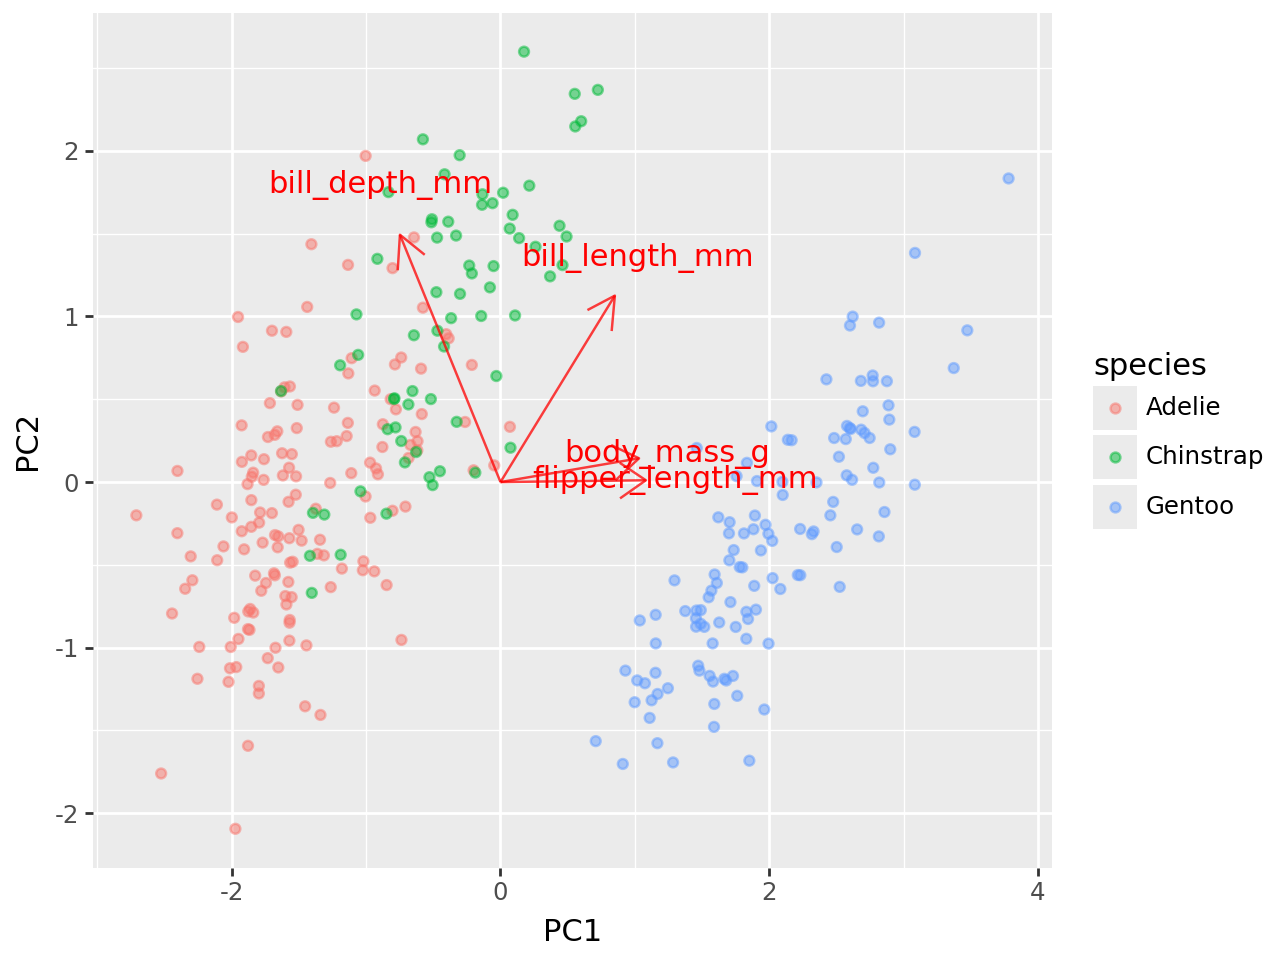

In [21]:
biplot(penguins, ploadings, color='species')